<a href="https://colab.research.google.com/github/FelipeConza/IntroduccionSistemasInformacion/blob/ExamenBimestral/ExmAIBimlFelipeConza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

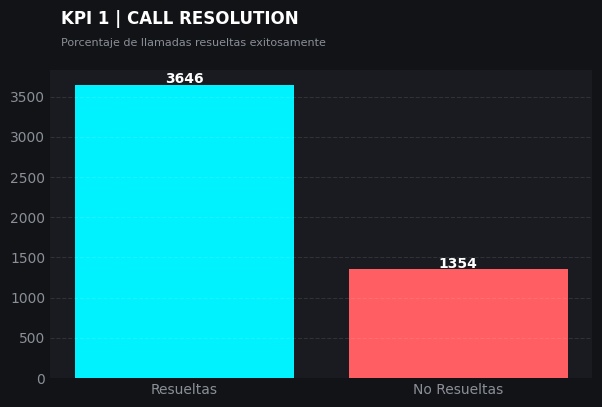

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

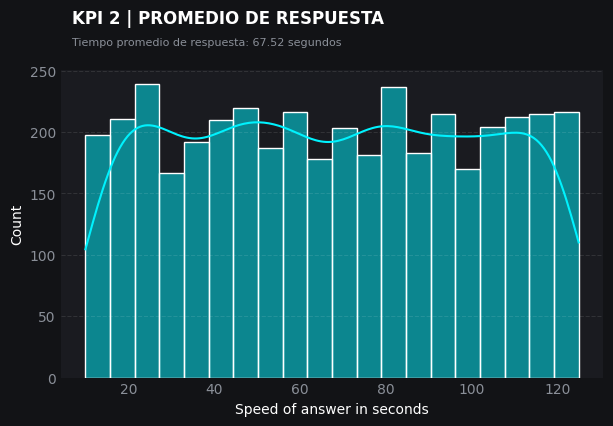

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

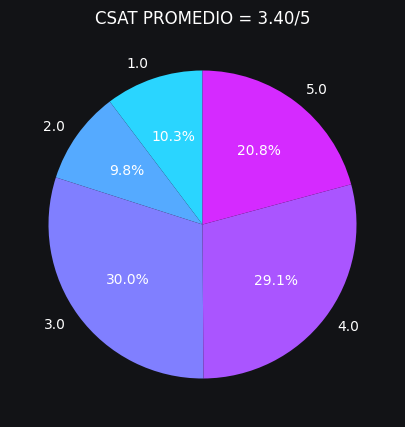

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

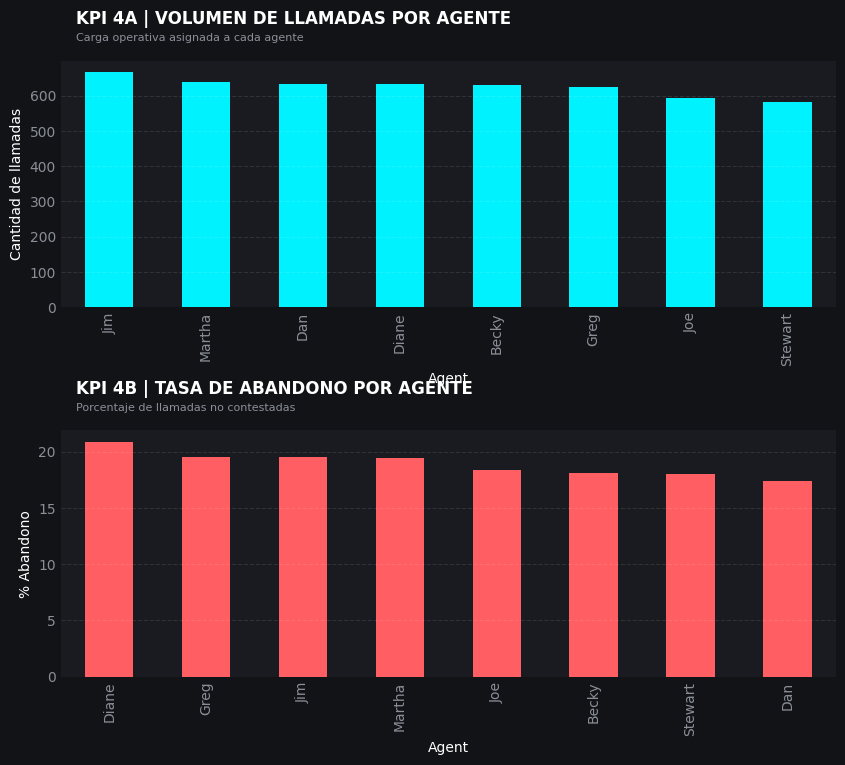

<IPython.core.display.Javascript object>

In [40]:
'''
Imports para usar la base de datos
uso de ecuaciones matemáticas
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import widgets

df = pd.read_excel("/content/01 Call-Center-Dataset.xlsx")

#KPI 1:  CR-Call Resolution

llamadas_resueltas = len(df[df["Resolved"] == "Y"])
total_llamadas = len(df)
cr = (llamadas_resueltas / total_llamadas) * 100

#KPI 2: ASA-Average Speed of Answer

asa = df["Speed of answer in seconds"].mean()

#KPI 3: CSAT Promedio

csat = df["Satisfaction rating"].mean()

#KPI 4: Volumen de Llamadas y Tasa de Abandono por Agente
volumen_agente = df.groupby("Agent").size()
abandono_agente = (df[df["Answered (Y/N)"] == "N"].groupby("Agent").size())

tasa_abandono = (abandono_agente/volumen_agente).fillna(0) * 100

agente_mayor_volumen = volumen_agente.idxmax()
cantidad_mayor_volumen = volumen_agente.max()

agente_mayor_abandono = tasa_abandono.idxmax()
porcentaje_mayor_abandono = tasa_abandono.max()

'''
Visaulización de los KPIs a modo de pestañas interactivas
para tener una mayor comodidad
'''
HEX_BG = '#121316'
HEX_CARD = '#1a1b20'
HEX_TEXT = '#ffffff'
HEX_MUTED = '#8a8f98'

plt.style.use('dark_background')

def estilizar_tarjeta_ui(ax, titulo, subtitulo):

    ax.set_facecolor(HEX_CARD)

    fig = ax.get_figure()
    fig.patch.set_facecolor(HEX_BG)

    ax.text( 0.02, 1.15, titulo, transform=ax.transAxes, fontsize=12, fontweight='bold', color=HEX_TEXT)

    ax.text(0.02, 1.08, subtitulo, transform=ax.transAxes, fontsize=8, color=HEX_MUTED)

    for spine in ['top','right','left','bottom']:
        ax.spines[spine].set_visible(False)

    ax.tick_params(colors=HEX_MUTED, length=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.1)

tb = widgets.TabBar([
    'Dashboard',
    'KPI 1',
    'KPI 2',
    'KPI 3',
    'KPI 4'
])

# DASHBOARD: VISUALIZACIÓN

with tb.output_to(0):

    print("="*75)
    print("                                 CALL CENTER")
    print("="*75)

    print(f"Total llamadas              :                 {total_llamadas:,}")

    print(f"Call Resolution (CR)        :                 {cr:.2f}%")

    print(f"ASA                         :                 {asa:.2f} segundos")

    print(f"CSAT                        :                 {csat:.2f}/5")

    print()

    print(f"Mayor volumen de llamadas   :                 {agente_mayor_volumen}")

    print(f"Cantidad de llamadas        :                 {cantidad_mayor_volumen:,}")

    print()

    print(f"Mayor tasa de abandono      :                 {agente_mayor_abandono}")

    print(f"Tasa de abandono            :                 {porcentaje_mayor_abandono:.2f}%")

    print("="*75)



#KPI 1: VISUALIZACIÓN

with tb.output_to(1):

    fig, ax = plt.subplots(figsize=(7,4))

    valores = [
        llamadas_resueltas,
        total_llamadas - llamadas_resueltas
    ]

    etiquetas = [
        "Resueltas",
        "No Resueltas"
    ]

    barras = ax.bar(
        etiquetas,
        valores,
        color=['#00f2fe','#ff5e62']
    )

    for bar in barras:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f"{int(bar.get_height())}",
            ha='center',
            color='white',
            fontweight='bold'
        )

    estilizar_tarjeta_ui(
        ax,
        "KPI 1 | CALL RESOLUTION",
        "Porcentaje de llamadas resueltas exitosamente"
    )

    plt.show()

#KPI 2: VISUALIZACIÓN

with tb.output_to(2):

    fig, ax = plt.subplots(figsize=(7,4))

    sns.histplot(
        df["Speed of answer in seconds"],
        bins=20,
        kde=True,
        color="#00f2fe",
        ax=ax
    )

    estilizar_tarjeta_ui(
        ax,
        "KPI 2 | PROMEDIO DE RESPUESTA",
        f"Tiempo promedio de respuesta: {asa:.2f} segundos"
    )

    plt.show()

#KPI 3: VISUALIZACIÓN

with tb.output_to(3):

    fig, ax = plt.subplots(figsize=(6,5))

    satisfaccion = (
        df["Satisfaction rating"]
        .value_counts()
        .sort_index()
    )

    ax.pie(
        satisfaccion,
        labels=satisfaccion.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("cool", len(satisfaccion))
    )

    fig.patch.set_facecolor(HEX_BG)

    ax.set_title(
        f"CSAT PROMEDIO = {csat:.2f}/5",
        color='white',
        fontsize=12
    )

    plt.show()

#KPI 4: VISUALIZACIÓN

with tb.output_to(4):

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(10,8)
    )

    plt.subplots_adjust(hspace=0.5)

    # GRÁFICO 1: VOLUMEN DE LLAMADAS POR AGENTE

    volumen_agente.sort_values(
        ascending=False
    ).plot(
        kind='bar',
        color='#00f2fe',
        ax=ax1
    )

    estilizar_tarjeta_ui(
        ax1,
        "KPI 4A | VOLUMEN DE LLAMADAS POR AGENTE",
        "Carga operativa asignada a cada agente"
    )

    ax1.set_ylabel("Cantidad de llamadas")

    # GRÁFICO 2: TASA DE ABANDONO

    tasa_abandono.sort_values(
        ascending=False
    ).plot(
        kind='bar',
        color='#ff5e62',
        ax=ax2
    )

    estilizar_tarjeta_ui(
        ax2,
        "KPI 4B | TASA DE ABANDONO POR AGENTE",
        "Porcentaje de llamadas no contestadas"
    )

    ax2.set_ylabel("% Abandono")

    plt.show()


In [41]:
'''
ESTO ES PARA LA VISUALIZACIÓN UNICAMENTE DE CADA UNO DE LOS EMPLEADOS DE
MANERA MÁS PRECISA DEL KPI 4
'''
reporte_agentes = pd.DataFrame({
    'Volumen de llamadas': volumen_agente,
    'Tasa de abandono (%)': tasa_abandono.round(2)
})

reporte_agentes = reporte_agentes.sort_values(
    by='Volumen de llamadas',
    ascending=False
)

print(reporte_agentes)

         Volumen de llamadas  Tasa de abandono (%)
Agent                                             
Jim                      666                 19.52
Martha                   638                 19.44
Dan                      633                 17.38
Diane                    633                 20.85
Becky                    631                 18.07
Greg                     624                 19.55
Joe                      593                 18.38
Stewart                  582                 18.04


Reporte de Indicadores Clave de Rendimiento (KPIs) – Call Center
KPI 1: Tasa de Resolución en la Llamada (CR)

Valor obtenido: 72.92%

Este indicador refleja el porcentaje de llamadas que fueron resueltas satisfactoriamente durante el primer contacto con el cliente. Un valor elevado evidencia que los agentes poseen los conocimientos y recursos necesarios para solucionar los requerimientos de manera eficiente, reduciendo la necesidad de llamadas repetidas y mejorando la experiencia del usuario.

KPI 2: Tiempo Promedio de Respuesta (ASA)

Valor obtenido: 67.52 segundos

El ASA representa el tiempo promedio que los clientes deben esperar antes de ser atendidos por un agente. Un tiempo de espera reducido indica una adecuada capacidad operativa y una correcta asignación de recursos humanos y tecnológicos dentro del centro de contacto.

KPI 3: Nivel de Satisfacción del Cliente (CSAT)

Valor obtenido: 3.4 / 5

Este indicador mide la percepción de los clientes respecto a la calidad del servicio recibido. Un valor alto refleja una experiencia positiva durante la atención y fortalece la fidelización de los usuarios, contribuyendo al cumplimiento de los objetivos de servicio de la organización.

KPI 4: Volumen de Llamadas y Tasa de Abandono por Agente

Valor obtenido:

| Agente  | Volumen de llamadas | Tasa de abandono (%) |
| ------- | ------------------: | -------------------: |
| Becky   |                 666 |                19.52 |
| Dan     |                 638 |                19.44 |
| Diane   |                 633 |                17.38 |
| Greg    |                 633 |                20.85 |
| Joe     |                 631 |                18.07 |
| Jim     |                 624 |                19.55 |
| Martha  |                 593 |                18.38 |
| Stewart |                 588 |                18.04 |


La comparación entre el volumen de llamadas y la tasa de abandono permite evaluar la carga operativa y el desempeño individual de cada agente. Los agentes con mayores tasas de abandono representan posibles cuellos de botella dentro del proceso de atención y pueden requerir redistribución de carga o capacitación adicional.